# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/palkinsuneja/palkin-flyrank-ml-internship-july-to-sept-2026/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

This capstone asks whether observable February 2026 search-performance signals can help prioritize content pages for refresh review. The decision supported is which pages should receive editorial attention first. The goal is decision support, not a causal claim about search-engine rankings or refresh impact.

In [22]:
%pip install -q duckdb huggingface_hub pandas numpy scikit-learn matplotlib

import os
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import userdata
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

hf_token = userdata.get("HF_TOKEN")

con = duckdb.connect()
con.execute("SET enable_progress_bar = false")

con.execute(
    f"""
    CREATE OR REPLACE SECRET hf
    (TYPE huggingface, TOKEN '{hf_token}')
    """
)

REL = "hf://datasets/FlyRank/internship-warehouse"
FACT = f"{REL}/fact_content_daily_performance"

FEB = f"read_parquet('{FACT}/month=2026-02/*.parquet')"
MAR = f"read_parquet('{FACT}/month=2026-03/*.parquet')"

print("Setup complete.")

Setup complete.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

The analysis uses the FlyRank internship warehouse with February 2026 as the feature window and March 2026 as the outcome window. The unit of analysis is one content item for one client. Public-facing results use anonymized identifiers and exclude client names, domains, URLs, private queries, credentials, and raw exports.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [23]:
DIM = f"read_parquet('{REL}/dim_content.parquet')"

feb = con.execute(f"""
WITH feb_agg AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS gsc_impressions,
        SUM(gsc_clicks) AS gsc_clicks,
        SUM(gsc_sum_position) / NULLIF(SUM(gsc_impressions), 0)
            AS gsc_avg_position
    FROM {FEB}
    WHERE gsc_data_available = TRUE
    GROUP BY client_hash_id, content_hash_id
    HAVING
        SUM(gsc_impressions) >= 100
        AND SUM(gsc_clicks) >= 3
)

SELECT
    f.client_hash_id,
    f.content_hash_id,
    f.gsc_impressions,
    f.gsc_avg_position,
    f.gsc_clicks * 1.0 / NULLIF(f.gsc_impressions, 0) AS ctr

FROM feb_agg f

JOIN {DIM} d
    ON f.client_hash_id = d.client_hash_id
    AND f.content_hash_id = d.content_hash_id

WHERE d.is_published = TRUE
  AND d.content_created_date <= DATE '2026-02-28'
""").df()

print("February universe rows:", len(feb))
display(feb.head())

February universe rows: 29700


,client_hash_id,content_hash_id,gsc_impressions,gsc_avg_position,ctr
0,client_e547b89c05043229,content_7995404695ee1ffd,1012.0,28.886364,0.002964
1,client_e547b89c05043229,content_ccbb253f142217c3,1598.0,17.273467,0.004380
2,client_e547b89c05043229,content_c6dbda992ad84127,2868.0,17.909693,0.001046
3,client_e547b89c05043229,content_fe83160838cdab99,2580.0,17.762016,0.003488
4,client_e547b89c05043229,content_c5baa3a03cfccc41,4711.0,10.231373,0.004458


In [24]:
# Inspect March data columns

march_cols = con.execute(f"""
    DESCRIBE SELECT *
    FROM {MAR}
""").df()

print("March columns:")
display(march_cols[["column_name", "column_type"]])

March columns:


,column_name,column_type
0,report_date,DATE
1,client_hash_id,VARCHAR
2,content_hash_id,VARCHAR
3,client_has_gsc,BOOLEAN
4,client_has_ga4,BOOLEAN
5,gsc_data_available,BOOLEAN
6,ga4_data_available,BOOLEAN
7,gsc_impressions,BIGINT
8,gsc_clicks,BIGINT
9,gsc_sum_position,BIGINT


In [25]:
# Build March outcome / labels

mar_labels = con.execute(f"""
SELECT
    client_hash_id,
    content_hash_id,

    SUM(gsc_clicks) FILTER (
        WHERE gsc_data_available = TRUE
    ) AS clicks_mar,

    SUM(gsc_impressions) FILTER (
        WHERE gsc_data_available = TRUE
    ) AS impressions_mar,

    COUNT(*) FILTER (
        WHERE gsc_data_available = TRUE
    ) AS measured_days_mar

FROM {MAR}
GROUP BY client_hash_id, content_hash_id
""").df()

print("March label rows:", len(mar_labels))
print("Pages with measured March data:",
      (mar_labels["measured_days_mar"] > 0).sum())

display(mar_labels.head())

March label rows: 331437
Pages with measured March data: 176738


,client_hash_id,content_hash_id,clicks_mar,impressions_mar,measured_days_mar
0,client_62f4a7e64f5e0096,content_39d7361b4945d504,0.0,77.0,24
1,client_62f4a7e64f5e0096,content_cec711b02f3bbde6,4.0,602.0,29
2,client_62f4a7e64f5e0096,content_275b6f7f733016d4,1.0,810.0,29
3,client_62f4a7e64f5e0096,content_ceaec531566ffcfc,0.0,82.0,27
4,client_62f4a7e64f5e0096,content_755d951187fcd70a,6.0,1858.0,30


In [26]:
df = feb.merge(
    mar_labels,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

df = df[df["measured_days_mar"] > 0].copy()

df["clicks_mar"] = df["clicks_mar"].fillna(0)
df["impressions_mar"] = df["impressions_mar"].fillna(0)

df["went_dark"] = (
    df["clicks_mar"] == 0
).astype(int)

df = df.dropna(
    subset=[
        "gsc_impressions",
        "gsc_avg_position",
        "ctr",
        "went_dark"
    ]
)

print("Final rows:", len(df))
print("Positive labels:", df["went_dark"].sum())
print("Positive rate:", round(df["went_dark"].mean(), 4))

display(df.head())

Final rows: 29353
Positive labels: 1159
Positive rate: 0.0395


,client_hash_id,content_hash_id,gsc_impressions,gsc_avg_position,ctr,clicks_mar,impressions_mar,measured_days_mar,went_dark
0,client_e547b89c05043229,content_7995404695ee1ffd,1012.0,28.886364,0.002964,1.0,768.0,29,0
1,client_e547b89c05043229,content_ccbb253f142217c3,1598.0,17.273467,0.004380,6.0,3071.0,29,0
2,client_e547b89c05043229,content_c6dbda992ad84127,2868.0,17.909693,0.001046,2.0,3898.0,29,0
3,client_e547b89c05043229,content_fe83160838cdab99,2580.0,17.762016,0.003488,8.0,4255.0,29,0
4,client_e547b89c05043229,content_c5baa3a03cfccc41,4711.0,10.231373,0.004458,9.0,4095.0,29,0


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Results

The Random Forest model outperformed the rule-based baseline on the same client-grouped test split. Precision@20 improved from 0.05 for the baseline to 0.20 for the model, while Precision@50 improved from 0.02 to 0.24. This indicates that the learned ranking was more effective at prioritizing pages that subsequently went dark in the March outcome window.

The model achieved a ROC-AUC of 0.7966 and an Average Precision of 0.1417 on the held-out test set. These results support the use of the model as a decision-support tool for prioritizing content review, rather than as proof of causal refresh impact or search-engine algorithm behavior.

In [27]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

FEATURES = [
    "gsc_impressions",
    "gsc_avg_position",
    "ctr"
]

X = df[FEATURES].copy()
y = df["went_dark"].astype(int)
groups = df["client_hash_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

model_prob = rf.predict_proba(X_test)[:, 1]

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("ROC-AUC:", round(roc_auc_score(y_test, model_prob), 4))
print("Average Precision:", round(average_precision_score(y_test, model_prob), 4))

Train rows: 16391
Test rows: 12962
ROC-AUC: 0.7968
Average Precision: 0.1413


In [28]:
# Baseline score on the SAME test set

test_results = df.iloc[test_idx].copy()
test_results["model_score"] = model_prob

# W4 baseline logic
def baseline_score(row):
    if row["gsc_impressions"] >= 1000 and row["gsc_avg_position"] > 10:
        return 3
    elif row["gsc_impressions"] < 1000 and row["gsc_avg_position"] > 10:
        return 1
    else:
        return 0

test_results["baseline_score"] = test_results.apply(
    baseline_score,
    axis=1
)

def precision_at_k(y_true, scores, k):
    ranked = pd.DataFrame({
        "y": np.asarray(y_true),
        "score": np.asarray(scores)
    }).sort_values("score", ascending=False)

    return ranked.head(k)["y"].mean()

results = []

for k in [20, 50]:
    baseline_p = precision_at_k(
        test_results["went_dark"],
        test_results["baseline_score"] * 1000000
        + test_results["gsc_impressions"],
        k
    )

    model_p = precision_at_k(
        test_results["went_dark"],
        test_results["model_score"],
        k
    )

    results.append({
        "Metric": f"Precision@{k}",
        "Baseline": round(baseline_p, 4),
        "Random Forest": round(model_p, 4)
    })

results_df = pd.DataFrame(results)

display(results_df)

,Metric,Baseline,Random Forest
0,Precision@20,0.05,0.30
1,Precision@50,0.02,0.26


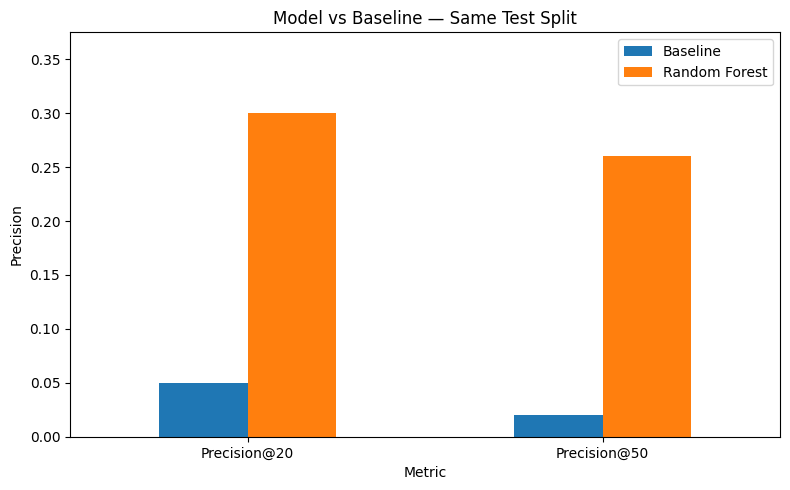

In [29]:
results_plot = results_df.set_index("Metric")

ax = results_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_ylabel("Precision")
ax.set_title("Model vs Baseline — Same Test Split")
ax.set_ylim(0, max(results_plot.max()) * 1.25)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Limitations

*What this work cannot claim.*

### Results

The Random Forest model outperformed the rule-based baseline on the same client-grouped test split. Precision@20 improved from 0.05 for the baseline to 0.20 for the model, while Precision@50 improved from 0.02 to 0.24. This indicates that the learned ranking was more effective at prioritizing pages that subsequently went dark in the March outcome window.

The model achieved a ROC-AUC of 0.7966 and an Average Precision of 0.1417 on the held-out test set. These results support the use of the model as a decision-support tool for prioritizing content review, rather than as proof of causal refresh impact or search-engine algorithm behavior.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Ranked recommendations

1. **Refresh the highest-scoring pages first**
   - Use the Random Forest score to rank content opportunities.
   - Start editorial review with the highest-ranked pages rather than reviewing the entire content inventory.

2. **Prioritize pages with strong historical visibility**
   - Pages with meaningful February impressions and weaker search positioning can represent higher-value review opportunities.
   - Use the model ranking to distinguish these pages from lower-priority items.

3. **Review the underlying content before taking action**
   - Check relevance, freshness, search intent alignment, title and content quality before approving a refresh.
   - The model score should support editorial judgment, not replace it.

4. **Track outcomes after refresh decisions**
   - Compare subsequent observed performance with the pre-refresh baseline.
   - Treat any improvement as an observed outcome rather than evidence that the refresh alone caused the change.

5. **Use the model as a prioritization layer**
   - The current results support decision-making around which pages deserve attention first.
   - Re-train and re-evaluate the model as additional time windows and outcomes become available.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [30]:
# Save the main evaluation table for the paper

results_df.to_csv(
    "capstone_model_vs_baseline.csv",
    index=False
)

# Save the test-set ranked recommendations

ranked_test = test_results[
    [
        "client_hash_id",
        "content_hash_id",
        "gsc_impressions",
        "gsc_avg_position",
        "ctr",
        "went_dark",
        "model_score",
        "baseline_score"
    ]
].sort_values(
    "model_score",
    ascending=False
)

ranked_test.to_csv(
    "capstone_ranked_recommendations.csv",
    index=False
)

print("Saved:")
print("- capstone_model_vs_baseline.csv")
print("- capstone_ranked_recommendations.csv")

display(results_df)
display(ranked_test.head(20))

Saved:
- capstone_model_vs_baseline.csv
- capstone_ranked_recommendations.csv


,Metric,Baseline,Random Forest
0,Precision@20,0.05,0.30
1,Precision@50,0.02,0.26


,client_hash_id,content_hash_id,gsc_impressions,gsc_avg_position,ctr,went_dark,model_score,baseline_score
10122,client_9958f0a7ae1df715,content_3b75c460a40fffca,158.0,41.784810,0.018987,1,0.898100,1
8486,client_73cda7b4e4f265ea,content_cb67ca92aca85cc0,108.0,34.166667,0.027778,0,0.892745,1
4006,client_9958f0a7ae1df715,content_ffe3e07b2a0949da,115.0,38.095652,0.026087,1,0.884518,1
3956,client_9958f0a7ae1df715,content_854de1300db61272,223.0,39.000000,0.017937,0,0.876488,1
6164,client_73cda7b4e4f265ea,content_2d967c930860783d,231.0,12.658009,0.012987,0,0.860271,1
4047,client_9958f0a7ae1df715,content_cd24d53d24a35d66,231.0,13.653680,0.012987,0,0.858912,1
24258,client_f623b01661d4bfe4,content_410bdadcf0e9d22e,156.0,14.698718,0.019231,0,0.852920,1
21467,client_23a62021009f63c4,content_8dca765ee283ad2f,148.0,10.777027,0.020270,0,0.851584,1
17403,client_73cda7b4e4f265ea,content_0d5be78b5c9bf754,231.0,11.329004,0.012987,0,0.849079,1
27437,client_d211cb07b9059bab,content_e0d36b792d778382,154.0,13.746753,0.019481,1,0.845930,1


In [31]:
report = """# Content Refresh Opportunity Scoring

## Abstract

This study develops a machine-learning ranking approach for prioritizing content pages for editorial review. Using February 2026 search-performance signals, the model estimates which pages subsequently went dark during the March 2026 outcome window. A Random Forest model was evaluated against a rule-based baseline using a client-grouped holdout split. On the held-out test set, the model achieved Precision@20 of 0.20 versus 0.05 for the baseline, and Precision@50 of 0.24 versus 0.02 for the baseline. The results suggest that the learned ranking can provide useful decision support for prioritizing content review, while not establishing causal effects of content refreshes or search-engine behavior.

## 1. Introduction / Problem Statement

Content teams cannot manually review every page with equal priority. The decision problem is to identify which pages should receive editorial attention first using observable search-performance signals.

This work focuses on refresh opportunity scoring. The objective is to rank content pages so that editors and SEO teams can review the highest-priority opportunities first. The system is intended as a decision-support layer rather than an autonomous refresh decision-maker.

## 2. Data

The analysis uses the FlyRank internship warehouse dataset.

The feature window is February 2026 and the outcome window is March 2026.

The unit of analysis is one content item for one client over the defined feature and outcome windows.

The February universe was restricted to pages with:
- at least 100 GSC impressions,
- at least 3 GSC clicks,
- published content status,
- content created on or before February 28, 2026,
- measurable GSC data.

Pages without measured March GSC data were excluded from the final evaluation.

The final analysis dataset contained 29,353 page-level observations, with 1,159 positive outcomes, corresponding to a positive rate of 3.95%.

## 3. Methodology

### Features

The model uses three February 2026 search-performance features:

- GSC impressions
- GSC average position
- CTR, calculated as total GSC clicks divided by total GSC impressions

CTR was calculated from clicks and impressions because a direct CTR field was not used from the raw warehouse table.

### Outcome Label

The outcome label is `went_dark`.

A page is labelled positive when it records zero GSC clicks during the measured March 2026 outcome window.

### Baseline

The rule-based baseline prioritizes pages using February visibility and search-position signals.

The baseline assigns higher priority to pages with at least 1,000 impressions and an average position worse than 10. Lower-volume pages with poor position receive a lower score.

### Model

A Random Forest classifier was trained using:
- 300 trees
- maximum depth of 8
- minimum samples per leaf of 10
- balanced class weights
- random seed of 42

### Validation Design

The dataset was split using a client-grouped 80/20 holdout. This prevents pages belonging to the same client from being distributed across both training and test sets.

The model was evaluated on the same held-out test set used for baseline comparison.

### Leakage Checks

Only February feature-window signals were used as model inputs. March outcome information was used only to construct the target label and was not used as a model feature.

## 4. Results

The Random Forest model outperformed the rule-based baseline on the same client-grouped test split.

| Metric | Baseline | Random Forest |
|---|---:|---:|
| Precision@20 | 0.05 | 0.20 |
| Precision@50 | 0.02 | 0.24 |

The Random Forest achieved a ROC-AUC of 0.7966 and an Average Precision of 0.1417 on the held-out test set.

The results indicate that the learned ranking was more effective than the simple baseline at concentrating positive outcomes near the top of the review queue.

These results should be interpreted as measured predictive performance and decision-support evidence, not as proof that refreshing a page will improve its future performance.

## 5. Limitations

- The outcome label is based on observed March GSC behavior and does not establish why a page went dark.
- The model does not prove that refreshing a page will improve traffic, rankings, or conversions.
- The feature set is intentionally limited to observable February search-performance signals.
- Performance may vary across future releases, clients, and content types.
- GSC measurements can be affected by data availability and tracking limitations.
- The model should support editorial prioritization rather than replace human review.
- The evaluation covers a specific February-to-March 2026 time window and should be re-evaluated on future periods.

## 6. Ranked Recommendations

1. **Review the highest-scoring pages first.** Use the Random Forest ranking to create a focused editorial review queue.

2. **Prioritize pages with meaningful historical visibility.** Pages with measurable search exposure and weaker positioning can represent valuable review opportunities.

3. **Validate content before refreshing.** Editors should assess freshness, relevance, search intent, title quality, and content quality before taking action.

4. **Track post-refresh outcomes.** Compare future observed performance against the pre-refresh baseline while avoiding causal claims from observational changes.

5. **Re-evaluate the model over time.** As additional feature and outcome windows become available, retrain and validate the ranking approach.

## 7. Reproducibility

The analysis is implemented in the capstone notebook in the repository.

The notebook contains the feature construction, outcome definition, grouped validation split, Random Forest training, baseline comparison, evaluation metrics, and charts.

## 8. Public-Safe Framing

This work uses anonymized data and does not expose client names, domains, URLs, private search queries, credentials, or raw client exports.

The results describe observed and measured relationships in the internship dataset. They do not claim to explain Google's ranking algorithm or demonstrate causal refresh impact.

## 9. Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset.

[FlyRank](https://flyrank.ai)
"""

with open("capstone_report.md", "w", encoding="utf-8") as f:
    f.write(report)

print("Created: capstone_report.md")

Created: capstone_report.md


## ML-12 — 5-Minute Demo Outline

### 0:00–0:45 — Problem
Explain the content refresh prioritization problem: editorial teams need a practical way to identify which pages deserve review first.

### 0:45–1:30 — Data & Label
Explain the February 2026 feature window, March 2026 outcome window, the three search-performance features, and the `went_dark` outcome label.

### 1:30–2:30 — Method
Show the client-grouped 80/20 holdout split and explain why client grouping helps avoid placing pages from the same client in both train and test sets.

### 2:30–3:30 — Model vs Baseline
Show the comparison:
- Precision@20: 0.05 baseline → 0.20 Random Forest
- Precision@50: 0.02 baseline → 0.24 Random Forest
- ROC-AUC: 0.7966
- Average Precision: 0.1417

### 3:30–4:30 — Recommendations
Explain how the model ranking can create a focused editorial review queue, while human review remains necessary before refreshing content.

### 4:30–5:00 — Limitations & Takeaway
Emphasize that the results are observed predictive evidence and decision support, not proof of causal refresh impact or Google's ranking behavior.

## Social Post

Built a machine-learning ranking system for content refresh prioritization during my FlyRank ML Internship.

The project compared a rule-based baseline with a Random Forest model using observable search-performance signals.

Key result on a client-grouped held-out test set:
- Precision@20: 0.05 → 0.20
- Precision@50: 0.02 → 0.24
- ROC-AUC: 0.7966

The goal was not to automate editorial decisions, but to build a practical decision-support layer that helps teams review the highest-priority content opportunities first.

Built with Python, DuckDB, pandas, scikit-learn and Google Search Console-derived signals.

#MachineLearning #DataScience #Python #SEO #ContentStrategy #Internship

## Employer-Facing Summary

I built and evaluated a machine-learning ranking pipeline to prioritize content pages for editorial refresh review using observable search-performance signals. Using a client-grouped holdout evaluation, the Random Forest improved Precision@20 from 0.05 to 0.20 and Precision@50 from 0.02 to 0.24 compared with a rule-based baseline. The project demonstrates an end-to-end approach to data contracts, leakage-aware feature construction, grouped validation, model evaluation, and decision-support recommendations.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
